## Homework 3 (KNN)
Дз по KNN-ну (я использовал датасет Anemia Types Classification https://www.kaggle.com/datasets/ehababoelnaga/anemia-types-classification/data?select=diagnosed_cbc_data_v4.csv) 

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import QuantileTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator
from sklearn import metrics
from sklearn.neighbors import VALID_METRICS
from sklearn.model_selection import GridSearchCV

df = pd.read_csv('diagnosed_cbc_data_v4.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1281 entries, 0 to 1280
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   WBC        1281 non-null   float64
 1   LYMp       1281 non-null   float64
 2   NEUTp      1281 non-null   float64
 3   LYMn       1281 non-null   float64
 4   NEUTn      1281 non-null   float64
 5   RBC        1281 non-null   float64
 6   HGB        1281 non-null   float64
 7   HCT        1281 non-null   float64
 8   MCV        1281 non-null   float64
 9   MCH        1281 non-null   float64
 10  MCHC       1281 non-null   float64
 11  PLT        1281 non-null   float64
 12  PDW        1281 non-null   float64
 13  PCT        1281 non-null   float64
 14  Diagnosis  1281 non-null   str    
dtypes: float64(14), str(1)
memory usage: 150.2 KB


## Обзор датасета

Датасет не имеет пропусков, типы данных вполне адекватные, датасет достаточно большой (1281 сэмплов), различных классов много, а именно:

In [2]:
diagnoses = pd.Series(df['Diagnosis'].unique())
print(diagnoses)
print('количество классов - {}'.format(len(diagnoses)))


0     Normocytic hypochromic anemia
1            Iron deficiency anemia
2           Other microcytic anemia
3                          Leukemia
4                           Healthy
5                  Thrombocytopenia
6    Normocytic normochromic anemia
7    Leukemia with thrombocytopenia
8                 Macrocytic anemia
dtype: str
количество классов - 9


И по количеству сэмплов разные классы насчитывают:

In [3]:
print(pd.DataFrame({diagnosis: df[df['Diagnosis'] == diagnosis].shape[0] for diagnosis in diagnoses}.items()))

                                0    1
0   Normocytic hypochromic anemia  279
1          Iron deficiency anemia  189
2         Other microcytic anemia   59
3                        Leukemia   47
4                         Healthy  336
5                Thrombocytopenia   73
6  Normocytic normochromic anemia  269
7  Leukemia with thrombocytopenia   11
8               Macrocytic anemia   18


Теперь посмотрим на распределения данных:

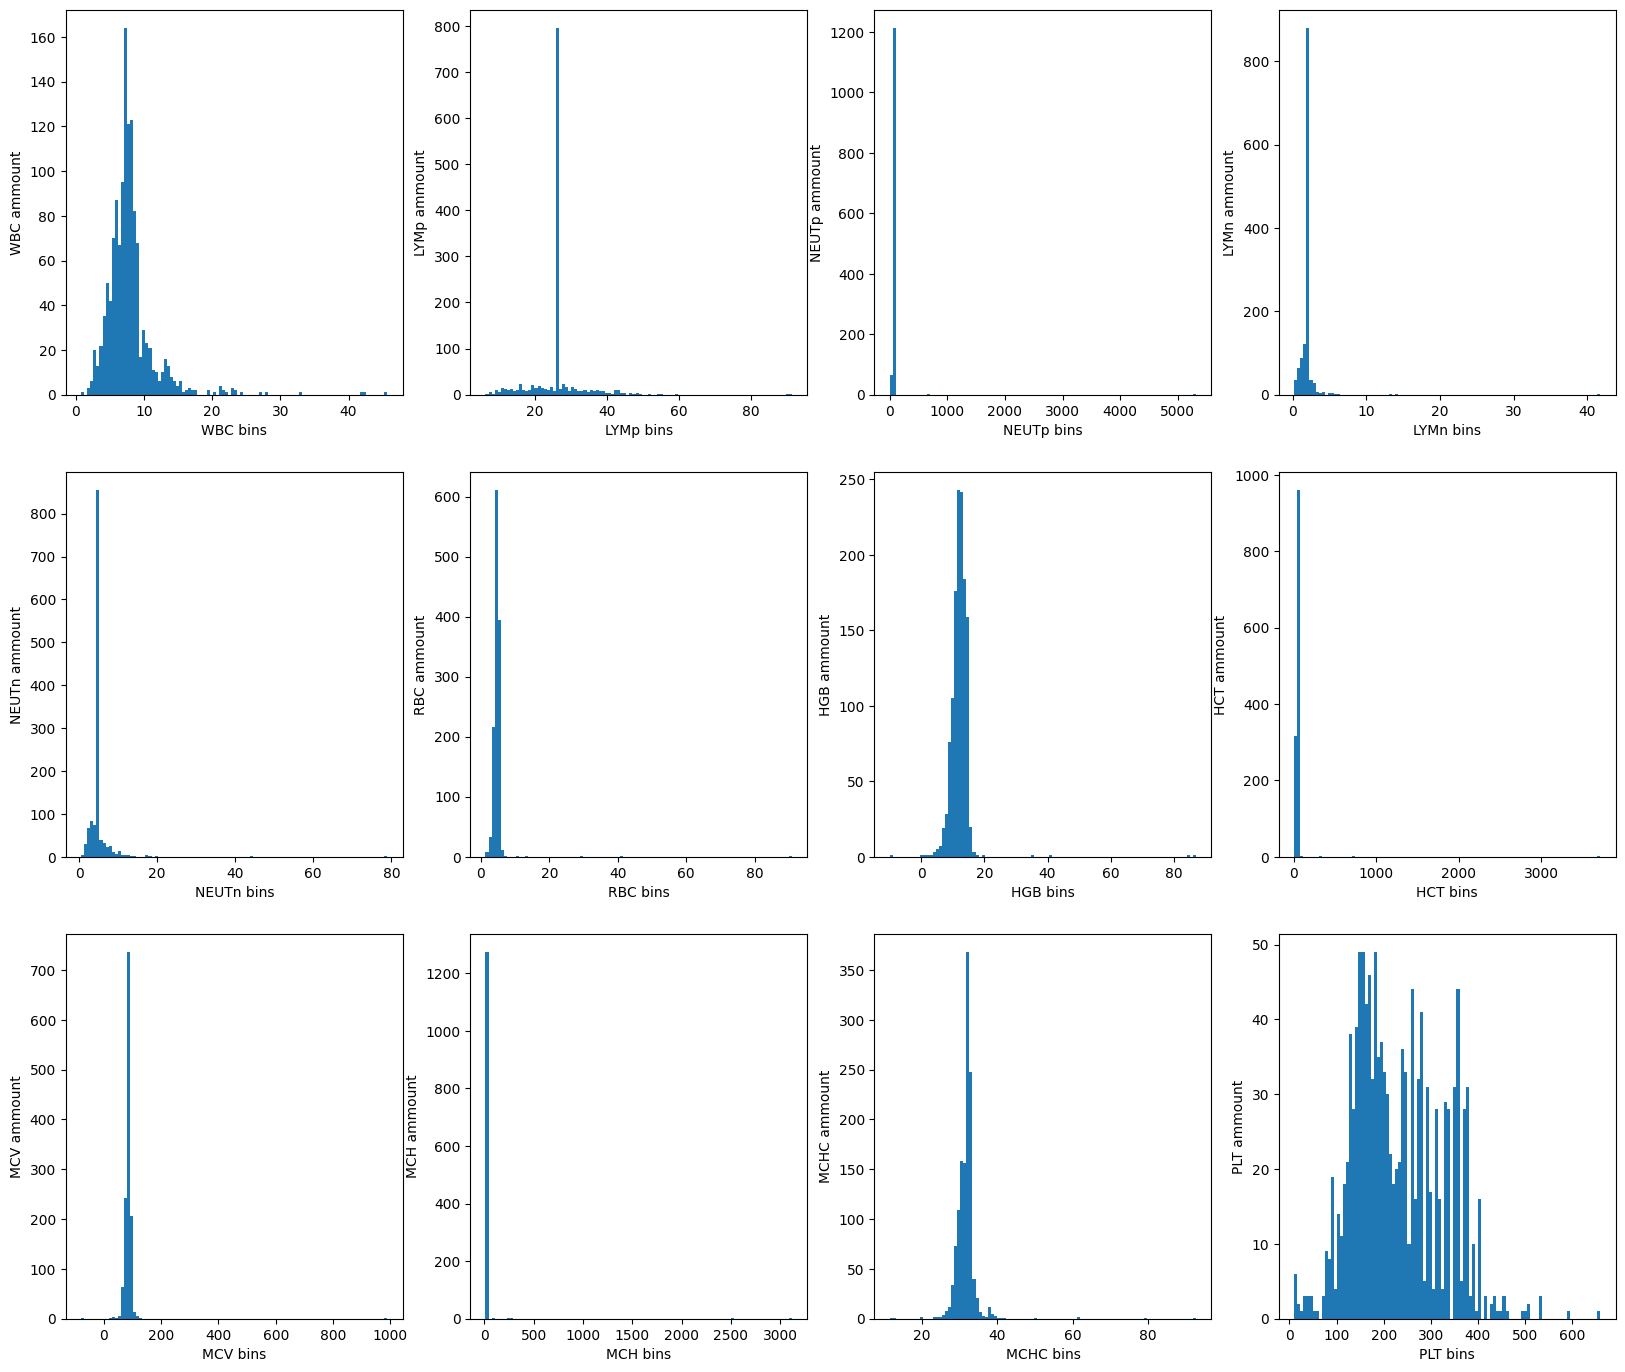

In [4]:
for ax, title in zip(plt.figure(figsize=(20, 17)).subplots(3, 4).ravel(), df.select_dtypes('float64').columns):
    ax.hist(df[title].values, bins=100)
    ax.set_xlabel(title + " bins")
    ax.set_ylabel(title + " ammount")


Видно, что во многих признаках есть выбросы и в основном распределения далеки от нормальных и уж точно от равномерных. Чтобы понять насколько распределения далеки от нормальных, подсчитаем следующие характеристики:

In [5]:
print("variance\n{}\n\nkurtosis\n{}\n\nskew:\n{}".format(df.select_dtypes('float64').var(), df.select_dtypes('float64').kurtosis(), df.select_dtypes('float64').skew()))

variance
WBC         12.705416
LYMp        49.543686
NEUTp    21828.961195
LYMn         1.784065
NEUTn        8.250071
RBC          7.936618
HGB         14.538185
HCT      11001.093974
MCV        738.625387
MCH      12358.937029
MCHC        10.892323
PLT       8652.596811
PDW          9.030498
PCT          0.469705
dtype: float64

kurtosis
WBC        27.922299
LYMp       13.185716
NEUTp    1238.608039
LYMn      633.188216
NEUTn     368.686047
RBC       708.353081
HGB       223.954436
HCT      1173.633426
MCV       959.882882
MCH       656.480040
MCHC      137.824620
PLT        -0.034169
PDW       448.526205
PCT       318.042902
dtype: float64

skew:
WBC       3.807032
LYMp      1.656549
NEUTp    34.946495
LYMn     22.114161
NEUTn    15.723494
RBC      24.573637
HGB      11.578004
HCT      33.729240
MCV      28.595933
MCH      25.408253
MCHC      8.243723
PLT       0.446357
PDW      16.599189
PCT      17.764033
dtype: float64


Как видно, у некоторых колонок (NEUTp, HCT, MCH, PLT) большая дисперсия. Почти у всех колонок очень большой эксцесс и почти все распределения имеют положительный коэффициент асимметрии.

Посмотрим на то, как признаки распределены по значениям (сильно ли отличаются диапазоны), просчитаем это и визуализируем.

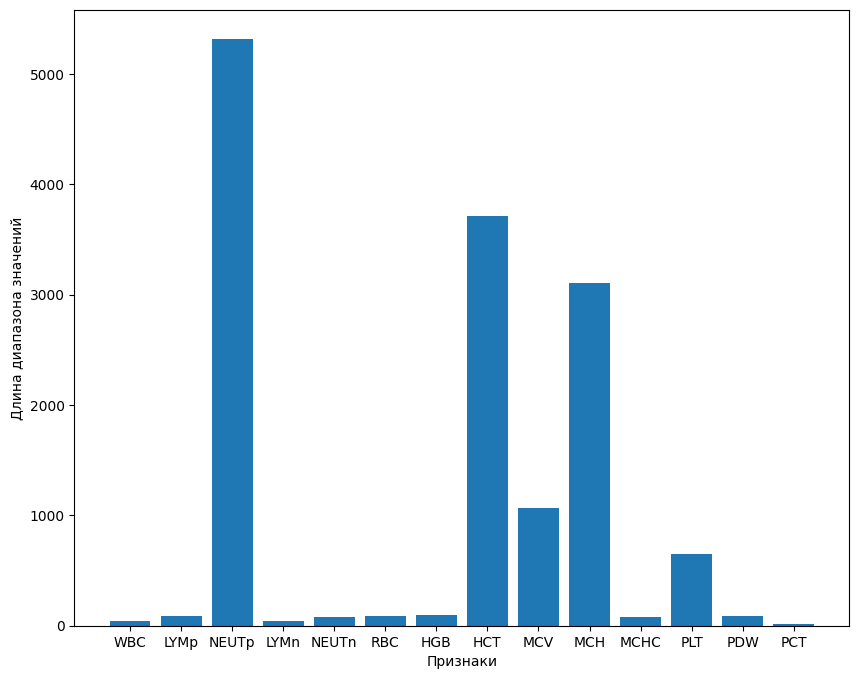

In [6]:


column_ranges = pd.Series(abs(df.select_dtypes('number').max().values - df.select_dtypes('number').min().values), index=df.select_dtypes('number').columns)
plt.figure(figsize=(10, 8))
plt.bar(range(len(column_ranges)), column_ranges)
plt.xticks(range(len(column_ranges)), column_ranges.index)
plt.xlabel('Признаки')
plt.ylabel('Длина диапазона значений')
plt.show()

Как видно на графике, разброс между диапазонами по величинам большой (особенно у тех величин, у которых большая дисперсия), поэтому нужно заняться масштабированием (в следующем пункте), т.к. в KNN используются метрики, которые чувствительны к таким различиям. 

KNN использует метрики, являющиеся расстоянием и веса соседей обычно тоже выбираются в зависимости от расстояния до предсказываемого экземпляра, поэтому шаг с масштабированием - обязательный (особенно в случае этих конкретных данных, т.к. очень большой разброс)

Теперь еще посмотрим на корреляцию с помощью heatmap.

<Axes: >

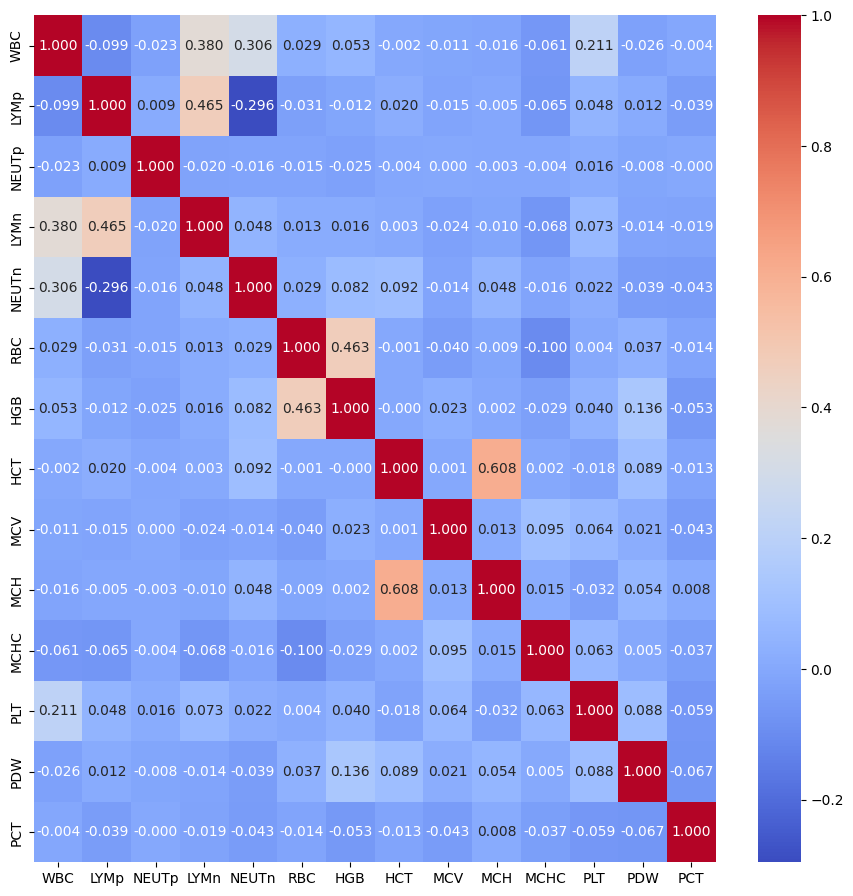

In [7]:
plt.figure(figsize= (11,11))
sns.heatmap(df.select_dtypes('number').corr(), annot=True, fmt=".3f", cmap='coolwarm')

Как видно на графике, признаки почти не коррелируют.

## Подготовка данных
Для начала сделаем таргет не строковым, а числовым значением с помощью `OrdinalEncoder`.

In [8]:
ec = OrdinalEncoder()
df_encoded = df.select_dtypes('number').join(pd.DataFrame(np.int64(ec.fit_transform(pd.DataFrame(df['Diagnosis'])))))
df_encoded.columns = df.columns

df_encoded.head()

,WBC,LYMp,NEUTp,LYMn,NEUTn,RBC,HGB,HCT,MCV,MCH,MCHC,PLT,PDW,PCT,Diagnosis
0,10.0,43.2,50.1,4.3,5.0,2.77,7.3,24.2,87.7,26.3,30.1,189.0,12.5,0.17,5
1,10.0,42.4,52.3,4.2,5.3,2.84,7.3,25.0,88.2,25.7,20.2,180.0,12.5,0.16,5
2,7.2,30.7,60.7,2.2,4.4,3.97,9.0,30.5,77.0,22.6,29.5,148.0,14.3,0.14,1
3,6.0,30.2,63.5,1.8,3.8,4.22,3.8,32.8,77.9,23.2,29.8,143.0,11.3,0.12,1
4,4.2,39.1,53.7,1.6,2.3,3.93,0.4,316.0,80.6,23.9,29.7,236.0,12.8,0.22,5


И еще получим маппинг этих числовых значений к исходным для удобства дальнейшей визуализации и понимания происходящего.

In [9]:
target_mapping = {name: index for index, name in enumerate(ec.categories_[0])}
reverse_target_mapping = {index: name for name, index in target_mapping.items()}
print(target_mapping)

{'Healthy': 0, 'Iron deficiency anemia': 1, 'Leukemia': 2, 'Leukemia with thrombocytopenia': 3, 'Macrocytic anemia': 4, 'Normocytic hypochromic anemia': 5, 'Normocytic normochromic anemia': 6, 'Other microcytic anemia': 7, 'Thrombocytopenia': 8}


Далее разделим датасет на  `df_train` и `df_test`.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(df_encoded.select_dtypes('float64'), df_encoded['Diagnosis'], random_state=42, stratify=df_encoded['Diagnosis'])
df_train = pd.DataFrame(X_train).join(y_train)
df_train.columns = df_encoded.columns
df_test = pd.DataFrame(X_test).join(y_test)
df_test.columns = df_encoded.columns

df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

print(df_train.info())
print('\n')
print(df_test.info())

<class 'pandas.DataFrame'>
RangeIndex: 960 entries, 0 to 959
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   WBC        960 non-null    float64
 1   LYMp       960 non-null    float64
 2   NEUTp      960 non-null    float64
 3   LYMn       960 non-null    float64
 4   NEUTn      960 non-null    float64
 5   RBC        960 non-null    float64
 6   HGB        960 non-null    float64
 7   HCT        960 non-null    float64
 8   MCV        960 non-null    float64
 9   MCH        960 non-null    float64
 10  MCHC       960 non-null    float64
 11  PLT        960 non-null    float64
 12  PDW        960 non-null    float64
 13  PCT        960 non-null    float64
 14  Diagnosis  960 non-null    int64  
dtypes: float64(14), int64(1)
memory usage: 112.6 KB
None


<class 'pandas.DataFrame'>
RangeIndex: 321 entries, 0 to 320
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  

Также было бы неплохо приблизить распределения признаков к нормальным с помощью `QuantileTransformer`. Это неплохо сделать (как мы убедимся позже) чтобы конечный результат вышел лучше.

In [11]:
tfn = QuantileTransformer(random_state=42, n_quantiles=df_train.shape[0], output_distribution='normal')
df_normal = pd.DataFrame(tfn.fit_transform(df_train.select_dtypes('float64'))).join(df_train['Diagnosis'])
df_normal.columns = df_train.columns
df_normal.head()

,WBC,LYMp,NEUTp,LYMn,NEUTn,RBC,HGB,HCT,MCV,MCH,MCHC,PLT,PDW,PCT,Diagnosis
0,-0.725417,-1.326823,1.559518,-1.512746,-0.811461,-0.535530,-0.457169,-0.888358,-0.135020,-0.409789,-0.547636,-0.690160,-0.782731,-0.905948,5
1,1.058373,2.468824,-1.925050,2.393598,-0.722021,-2.115224,-1.950682,-2.310598,0.185328,-0.431205,-0.880628,-0.242835,-1.065263,-0.649272,5
2,0.835306,-0.833455,-0.765099,1.382428,1.283932,0.706839,1.076859,-0.371702,0.016990,-0.011762,-0.136338,-0.306631,-1.165037,-0.761601,0
3,0.094236,0.033986,0.335529,0.104743,0.120526,0.399860,0.284786,0.454269,0.277988,0.483445,0.960489,0.710199,0.138977,0.462980,6
4,-0.725417,0.033986,0.335529,0.104743,0.120526,-1.022447,-0.660609,0.454269,-0.896141,-0.523501,0.154830,-0.095549,-0.432640,0.462980,7


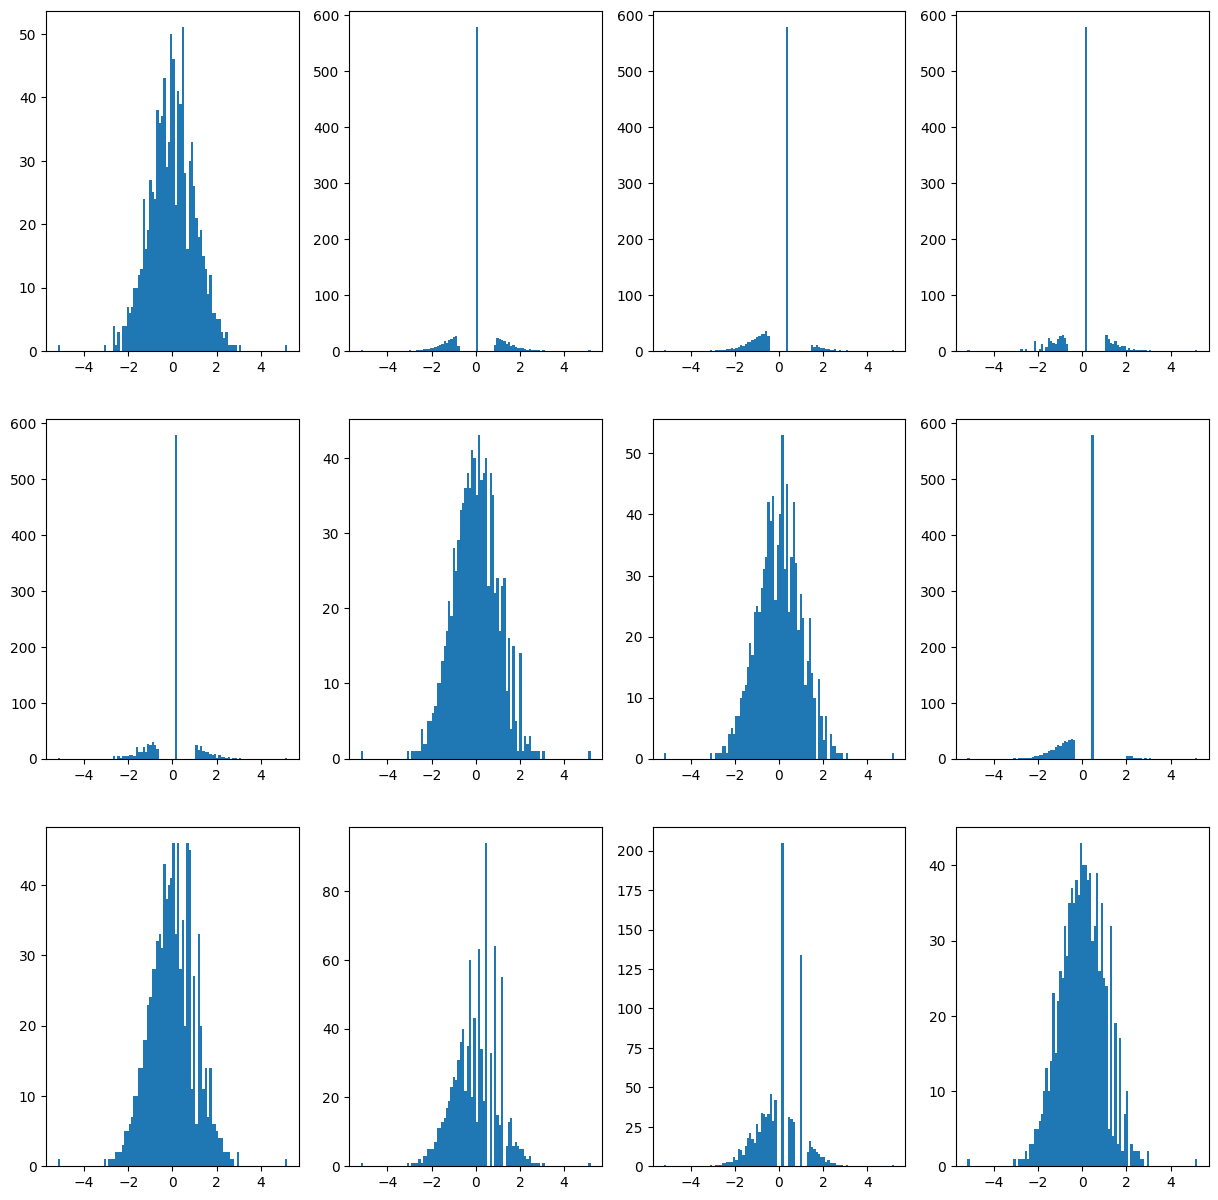

In [12]:
for ax, title in zip(plt.figure(figsize=(15,15)).subplots(3, 4).ravel(), df_normal.select_dtypes('number').columns):
    ax.hist(df_normal[title].values, bins=100)
    ax.set_xlabel('')

Сделаем еще для наглядности равномерное распределение также с помощью этого трансформера (в дальнейшем проверим какой из них лучше подходит).

In [13]:
tfu = QuantileTransformer(random_state=42, n_quantiles=df_train.shape[0], output_distribution='uniform')
df_uniform = pd.DataFrame(tfu.fit_transform(df_train.select_dtypes('float64'))).join(df_train['Diagnosis'])
df_uniform.columns = df_train.columns
df_uniform.head()

,WBC,LYMp,NEUTp,LYMn,NEUTn,RBC,HGB,HCT,MCV,MCH,MCHC,PLT,PDW,PCT,Diagnosis
0,0.234098,0.092284,0.940563,0.065172,0.208551,0.296142,0.323775,0.187174,0.446298,0.340980,0.291971,0.245047,0.216893,0.182482,5
1,0.855057,0.993222,0.027112,0.991658,0.235141,0.017205,0.025547,0.010428,0.573514,0.333160,0.189260,0.404067,0.143379,0.258081,5
2,0.798227,0.202294,0.222106,0.916580,0.900417,0.760167,0.859228,0.355057,0.506778,0.495308,0.445777,0.379562,0.122002,0.223149,0
3,0.537539,0.513556,0.631387,0.541710,0.547967,0.655370,0.612096,0.675182,0.609489,0.685610,0.831595,0.761210,0.555266,0.678311,6
4,0.234098,0.513556,0.631387,0.541710,0.547967,0.153285,0.254432,0.675182,0.185089,0.300313,0.561522,0.461940,0.332638,0.678311,7


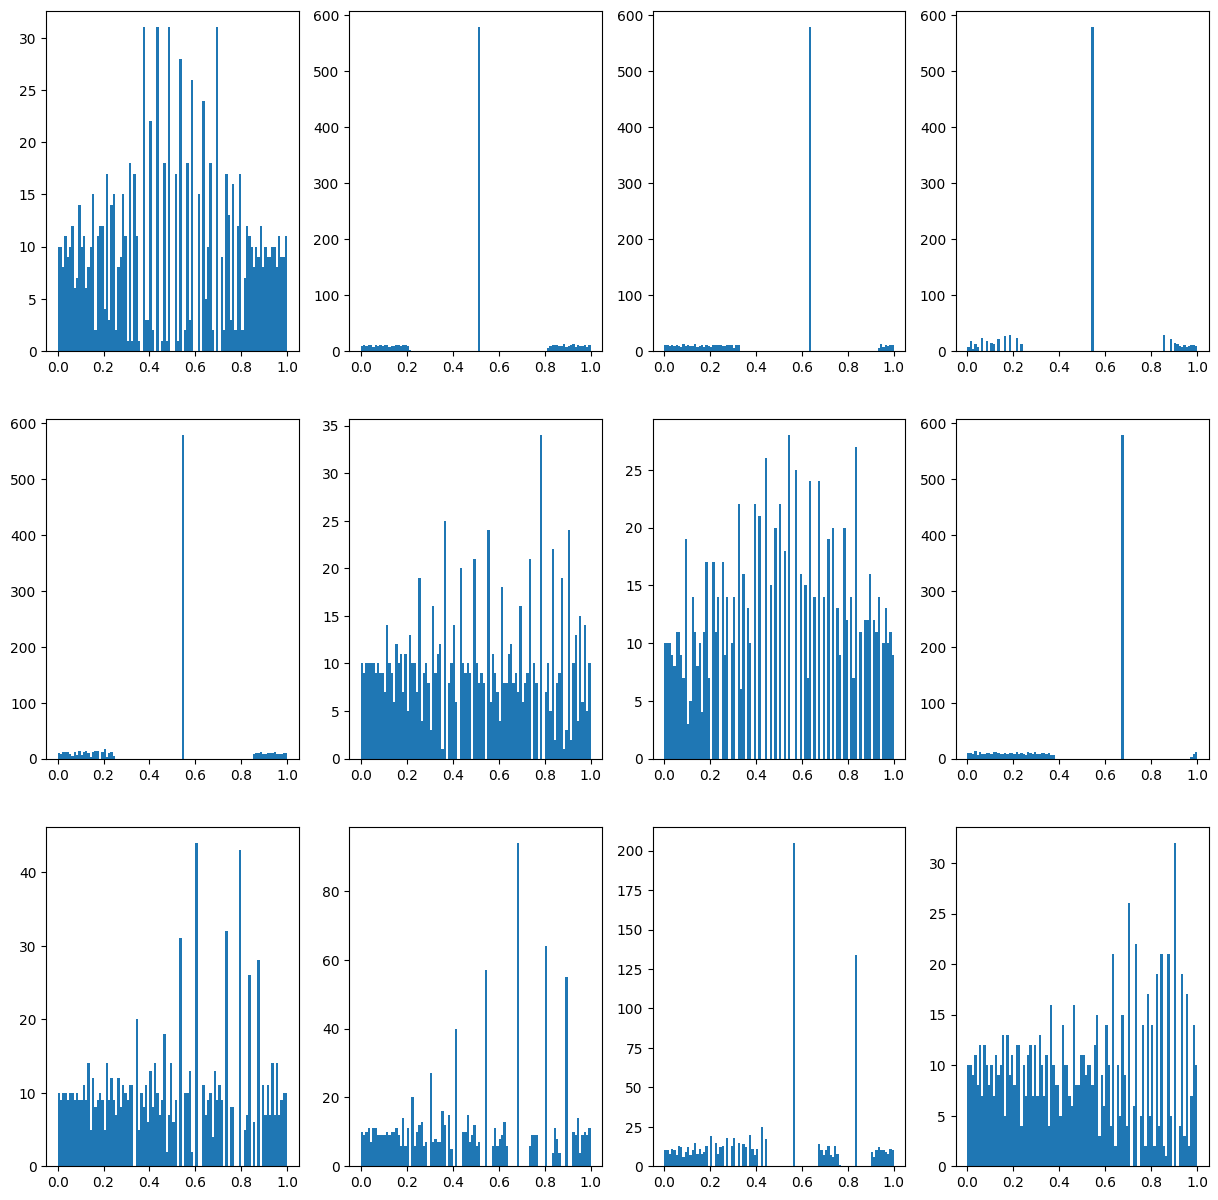

In [14]:
for ax, title in zip(plt.figure(figsize=(15,15)).subplots(3, 4).ravel(), df_uniform.select_dtypes('number').columns):
    ax.hist(df_uniform[title].values, bins=100)
    ax.set_xlabel('')

Трансформируем теперь тестовый датасет, используя уже созданные объекты `tfu` и `tfn`.

In [15]:
df_normal_test = pd.DataFrame(tfn.transform(df_test.select_dtypes('float64'))).join(df_test['Diagnosis'])
df_normal_test.columns = df_test.columns
print(df_normal_test.info())

df_uniform_test= pd.DataFrame(tfu.transform(df_test.select_dtypes('float64'))).join(df_test['Diagnosis'])
df_uniform_test.columns = df_test.columns
print('\n')
print(df_uniform_test.info())

<class 'pandas.DataFrame'>
RangeIndex: 321 entries, 0 to 320
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   WBC        321 non-null    float64
 1   LYMp       321 non-null    float64
 2   NEUTp      321 non-null    float64
 3   LYMn       321 non-null    float64
 4   NEUTn      321 non-null    float64
 5   RBC        321 non-null    float64
 6   HGB        321 non-null    float64
 7   HCT        321 non-null    float64
 8   MCV        321 non-null    float64
 9   MCH        321 non-null    float64
 10  MCHC       321 non-null    float64
 11  PLT        321 non-null    float64
 12  PDW        321 non-null    float64
 13  PCT        321 non-null    float64
 14  Diagnosis  321 non-null    int64  
dtypes: float64(14), int64(1)
memory usage: 37.7 KB
None


<class 'pandas.DataFrame'>
RangeIndex: 321 entries, 0 to 320
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -

Теперь посмотрим на дисперсию, эксцесс и коэффициент асимметрии для полученных `df_normal` и `df_uniform`.

In [16]:
print("variance\n{}\n\nkurtosis\n{}\n\nskew:\n{}".format(df_normal.select_dtypes('float64').var(), df_normal.select_dtypes('float64').kurtosis(), df_normal.select_dtypes('float64').skew()))

variance
WBC      1.042308
LYMp     0.911350
NEUTp    0.860782
LYMn     0.923292
NEUTn    0.924562
RBC      1.041425
HGB      1.042556
HCT      0.794384
MCV      1.041497
MCH      1.039867
MCHC     1.029866
PLT      1.041081
PDW      1.043880
PCT      0.804127
dtype: float64

kurtosis
WBC      1.010150
LYMp     2.183382
NEUTp    2.491807
LYMn     2.780885
NEUTn    2.787728
RBC      1.014646
HGB      1.017161
HCT      2.799310
MCV      1.015407
MCH      1.026723
MCHC     1.085889
PLT      1.013059
PDW      1.612083
PCT      3.561227
dtype: float64

skew:
WBC      0.001542
LYMp    -0.009935
NEUTp   -0.180752
LYMn    -0.151777
NEUTn   -0.163336
RBC     -0.001575
HGB      0.001054
HCT     -0.413003
MCV     -0.002107
MCH     -0.003160
MCHC    -0.010526
PLT     -0.003242
PDW     -0.105079
PCT     -0.582810
dtype: float64


In [17]:
print("variance\n{}\n\nkurtosis\n{}\n\nskew:\n{}".format(df_uniform.select_dtypes('float64').var(), df_uniform.select_dtypes('float64').kurtosis(), df_uniform.select_dtypes('float64').skew()))

variance
WBC      0.083574
LYMp     0.065341
NEUTp    0.065341
LYMn     0.065354
NEUTn    0.065363
RBC      0.083556
HGB      0.083562
HCT      0.065352
MCV      0.083535
MCH      0.083431
MCHC     0.082542
PLT      0.083559
PDW      0.081141
PCT      0.065369
dtype: float64

kurtosis
WBC     -1.199343
LYMp    -0.287524
NEUTp   -0.728429
LYMn    -0.329839
NEUTn   -0.342488
RBC     -1.200201
HGB     -1.199758
HCT     -1.074485
MCV     -1.199993
MCH     -1.200134
MCHC    -1.179663
PLT     -1.200542
PDW     -1.102080
PCT     -1.105788
dtype: float64

skew:
WBC      0.000004
LYMp    -0.044791
NEUTp   -0.431717
LYMn    -0.137540
NEUTn   -0.157841
RBC      0.000055
HGB      0.000325
HCT     -0.575180
MCV     -0.000819
MCH     -0.003287
MCHC    -0.014651
PLT     -0.000217
PDW     -0.017313
PCT     -0.584380
dtype: float64


То есть мы максимально приблизили данные к нормальному и равномерному распределению соответственно.

## Реализация модели
Я решил для начала попробовать реализовать свою модель. Я реализую свой класс, унаследовав `base.BaseEstimator` чтобы потом использовать его как финальный этап в `Pipline` и чтобы были функции `set_params` и `get_params` для более удобного подбора гиперпараметров.

In [18]:
class KNN(BaseEstimator):

    def __init__(self, *, n_neighbors=10, weights='uniform', metric='euclidean', p=2):
        self.n_neighbors=n_neighbors
        self.weights=weights
        self.metric=metric
        self.p = p
    
    def fit(self, X, y):
        self.X = np.array(X)
        self.y = np.array(y)
        return self

    def predict(self, X):
        X = np.array(X)
        dist = self.knneighbours(X)
        predictions = np.zeros(X.shape[0])
        if self.weights == 'uniform':
            for i in range(X.shape[0]):
                predicted_classes = np.array([self.y[int(dist[i, idx, 0])] for idx in range(self.n_neighbors)]).astype(int)
                predictions[i] = np.argmax(np.bincount(predicted_classes))
        elif self.weights == 'distance':
            for i in range(X.shape[0]):
                predicted_classes = np.int64(np.array([self.y[int(dist[i, idx, 0])] for idx in range(self.n_neighbors)])).astype(int)
                weights = np.array([ 1 / (dist[i, idx, 1] + 1e-10) for idx in range(self.n_neighbors)])
                predictions[i] = np.argmax(np.bincount(predicted_classes, weights=weights))
        else:
            pass
            
        return predictions
    
    def knneighbours(self, X_raw):
        res = []
        if(np.ndim(X_raw) == 1):
            X = np.atleast_2d(X_raw)
        else:
            X = X_raw
            
        for i in range(X.shape[0]):
            Z = self.X
            if self.metric == 'euclidean':
                dist = np.sqrt(np.sum(((Z - X[i]) ** 2), axis=1))
            elif self.metric == 'minkowski':
                dist = np.power(np.sum(np.abs(Z - X[i]) ** self.p, axis=1), 1 / self.p)
            elif self.metric == 'manhattan':
                dist = np.sum(np.absolute(Z - X[i]), axis=1)
            elif self.metric == 'cosine':
                dist = 1.0 - (np.sum(Z * X[i], axis=1) / (np.sqrt(np.sum(Z ** 2, axis=1)) * np.sqrt(np.sum(X[i] ** 2)) + 1e-10))
            else:
                pass
            indices = np.argsort(dist)[0:self.n_neighbors]
            res.append([[idx, dist[idx]] for idx in indices])
        return np.array(res)

In [19]:
classifier_custom = KNN()
classifier_custom.fit(df_normal.select_dtypes('float64'), df_normal['Diagnosis'])

,n_neighbors,10
,weights,'uniform'
,metric,'euclidean'
,p,2


Теперь еще создадим экземпляр класса `KNeighborsClassifier` чтобы потом сравнить результаты.

In [20]:
classifier = KNeighborsClassifier(n_neighbors=10)
classifier.fit(df_normal.select_dtypes('float64'), df_normal['Diagnosis'])

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",10
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


## Проверка результатов
Теперь попробуем посмотреть score моей модели и встроенной в sklearn. Для этого используем встоенные в sklearn функции подсчета score.

In [21]:
print(metrics.accuracy_score(df_normal_test['Diagnosis'], classifier.predict(df_normal_test.select_dtypes('float64'))))
print(metrics.f1_score(df_normal_test['Diagnosis'], classifier.predict(df_normal_test.select_dtypes('float64')), average=None))

0.7507788161993769
[0.81871345 0.75268817 0.23529412 0.         0.5        0.66666667
 0.9        0.69230769 0.56      ]


In [22]:
print(metrics.accuracy_score(df_normal_test['Diagnosis'], classifier_custom.predict(df_normal_test.select_dtypes('float64'))))
print(metrics.f1_score(df_normal_test['Diagnosis'], classifier_custom.predict(df_normal_test.select_dtypes('float64')), average=None))

0.7507788161993769
[0.81871345 0.75268817 0.23529412 0.         0.5        0.66666667
 0.9        0.69230769 0.56      ]


Получилось ровно одно и то же, что радует. Теперь проверим то же самое но для `df_uniform_test`.

In [23]:
classifier.fit(df_uniform.select_dtypes('float64'), df_uniform['Diagnosis'])
classifier_custom.fit(df_uniform.select_dtypes('float64'), df_uniform['Diagnosis'])


print(metrics.accuracy_score(df_uniform_test['Diagnosis'], classifier.predict(df_uniform_test.select_dtypes('float64'))))
print(metrics.f1_score(df_uniform_test['Diagnosis'], classifier.predict(df_uniform_test.select_dtypes('float64')), average=None))
print()

print(metrics.accuracy_score(df_uniform_test['Diagnosis'], classifier_custom.predict(df_uniform_test.select_dtypes('float64'))))
print(metrics.f1_score(df_uniform_test['Diagnosis'], classifier_custom.predict(df_uniform_test.select_dtypes('float64')), average=None))

0.7881619937694704
[0.875      0.7755102  0.35294118 0.         0.57142857 0.69736842
 0.91176471 0.64       0.71428571]

0.7881619937694704
[0.875      0.7755102  0.35294118 0.         0.57142857 0.69736842
 0.91176471 0.64       0.71428571]


И опять то же самое по accuracy. Однако четвертый класс имее очень плохой F1 score.

In [24]:
print(pd.DataFrame({reverse_target_mapping[diagnosis]: df_normal_test[df_normal_test['Diagnosis'] == diagnosis].shape[0] for diagnosis in target_mapping.values()}.items()))

                                0   1
0                         Healthy  84
1          Iron deficiency anemia  47
2                        Leukemia  12
3  Leukemia with thrombocytopenia   3
4               Macrocytic anemia   5
5   Normocytic hypochromic anemia  70
6  Normocytic normochromic anemia  67
7         Other microcytic anemia  15
8                Thrombocytopenia  18


## Кросс-валидация
Теперь попробуем подобрать гиперпараметры. Для начала посмотрим что будет при разных метриках.

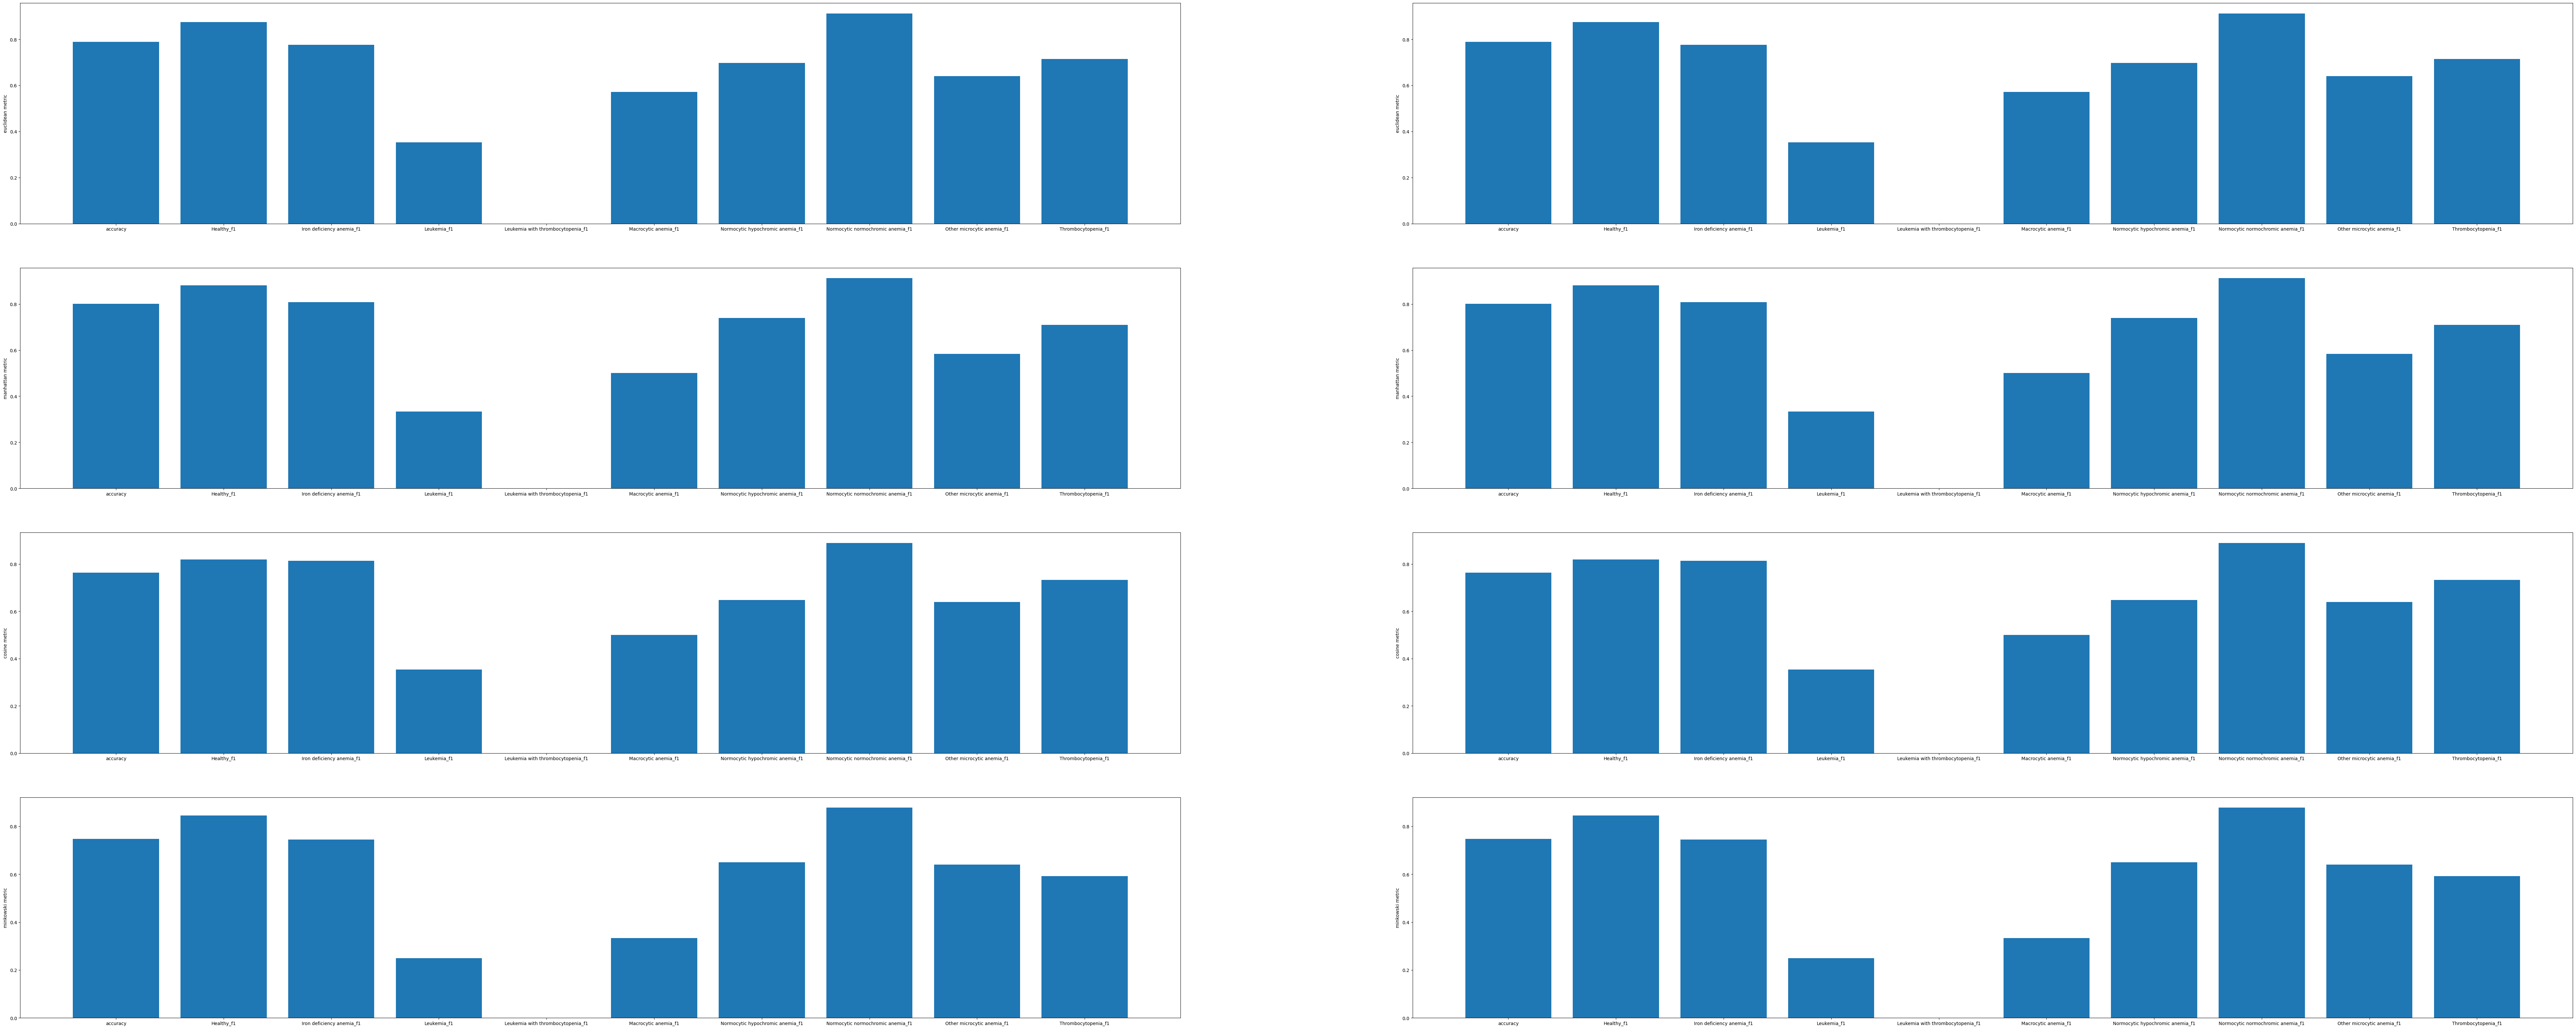

In [25]:
classifier = KNeighborsClassifier(n_neighbors=10, metric='manhattan')
classifier_custom = KNN(n_neighbors=10, metric='manhattan')

metric_names = ['euclidean', 'manhattan', 'cosine', 'minkowski']
    
metric_plots = plt.figure(figsize=(100,40)).subplots(4,2)

for m, i in zip(metric_names, range(len(metric_names))):
    classifier = KNeighborsClassifier(n_neighbors=10, metric=m, weights='uniform', p=3)
    classifier_custom = KNN(n_neighbors=10, metric=m, weights='uniform', p=3)

    classifier.fit(df_uniform.select_dtypes('float64'), df_uniform['Diagnosis'])
    classifier_custom.fit(df_uniform.select_dtypes('float64'), df_uniform['Diagnosis'])

    metric_plots[i][0].bar(
        x=['accuracy'] + [name + '_f1' for name in reverse_target_mapping.values()],
        height=np.concatenate([
                np.array([metrics.accuracy_score(df_uniform_test['Diagnosis'], classifier.predict(df_uniform_test.select_dtypes('float64')))]),
                metrics.f1_score(df_uniform_test['Diagnosis'], classifier.predict(df_uniform_test.select_dtypes('float64')), average=None)
            ])
        )
    metric_plots[i][0].set_ylabel(m + ' metric')

    metric_plots[i][1].bar(
        x=['accuracy'] + [name + '_f1' for name in reverse_target_mapping.values()],
        height=np.concatenate([
                np.array([metrics.accuracy_score(df_uniform_test['Diagnosis'], classifier_custom.predict(df_uniform_test.select_dtypes('float64')))]),
                metrics.f1_score(df_uniform_test['Diagnosis'], classifier_custom.predict(df_uniform_test.select_dtypes('float64')), average=None)
            ])
        )
    metric_plots[i][1].set_ylabel(m + ' metric')



Видно, как f1 score меняется в зависимости от метрики, в целом лучше всего работает расстояние Евклида.

Для того чтобы подобрать гиперпараметры, будем использовать grid search как самый простой метод. То сеть по сути переберем все возможные комбинации параметров.

In [26]:
print(KNeighborsClassifier().get_params())
print(KNN().get_params())

{'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}
{'metric': 'euclidean', 'n_neighbors': 10, 'p': 2, 'weights': 'uniform'}


Посмотрим какие метрики можно использовать для разных алгоритмов в `KNeighborsClassifier`.

In [27]:
for al in ['ball_tree','kd_tree','brute']:
    print(VALID_METRICS[al])

['euclidean', 'l2', 'minkowski', 'p', 'manhattan', 'cityblock', 'l1', 'chebyshev', 'infinity', 'seuclidean', 'mahalanobis', 'hamming', 'canberra', 'braycurtis', 'jaccard', 'dice', 'rogerstanimoto', 'russellrao', 'sokalmichener', 'sokalsneath', 'haversine', 'pyfunc']
['euclidean', 'l2', 'minkowski', 'p', 'manhattan', 'cityblock', 'l1', 'chebyshev', 'infinity']
['braycurtis', 'canberra', 'chebyshev', 'cityblock', 'correlation', 'cosine', 'dice', 'euclidean', 'hamming', 'haversine', 'jaccard', 'l1', 'l2', 'mahalanobis', 'manhattan', 'minkowski', 'nan_euclidean', 'precomputed', 'rogerstanimoto', 'russellrao', 'seuclidean', 'sokalsneath', 'sqeuclidean', 'yule']


Теперь применим `GridSearchCV` для перебора гиперпараметров.

In [28]:
params = [
{
    'algorithm':['ball_tree','kd_tree'],
    'leaf_size':list(range(1,50)),
    'metric':['minkowski', 'manhattan', 'euclidean'],
    'p':list(range(3, 20)),
    'weights':['uniform', 'distance'],
    'n_neighbors':list(range(1,20))
},
{
    'algorithm':['auto', 'brute'],
    'leaf_size':list(range(1,50)),
    'metric':['minkowski', 'cosine', 'manhattan', 'euclidean'],
    'p':list(range(3, 20)),
    'weights':['uniform', 'distance'],
    'n_neighbors':list(range(1,20))
}
]

params_custom = {
    'metric':['euclidean', 'minkowski', 'manhattan', 'cosine'],
    'n_neighbors':list(range(1,20)),
    'p':list(range(3, 20)),
    'weights':['uniform', 'distance']
}

gs = GridSearchCV(KNeighborsClassifier(), params, scoring='f1_macro', n_jobs=60)
gs_custom = GridSearchCV(KNN(), params_custom, scoring='f1_macro', n_jobs=60)

gs.fit(df_uniform.select_dtypes('float64').values, df_uniform['Diagnosis'].values)
gs_custom.fit(df_uniform.select_dtypes('float64').values, df_uniform['Diagnosis'].values)

best_params = gs.best_params_
best_params_custom = gs_custom.best_params_


Теперь посмотрим что получилось на выходе.

In [1]:
print(best_params)
print(best_params_custom)
print(gs.best_score_)
print(gs_custom.best_score_)

NameError: name 'best_params' is not defined